# 🧪 A/B Testing & Statistical Analysis
> **Notebook 3 of 4** — Run after `02_eda.ipynb`.
> A/B tests on pricing model, duration model, and the core rental vs. markdown hypothesis.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

Three tests in this notebook, each answering a distinct question:
1. **Pricing model** — does flat rate vs percentage-of-retail affect revenue per rental? (Welch's t-test)
2. **Duration model** — do the three duration tiers generate different revenue? (one-way ANOVA)
3. **Core hypothesis** — is rental revenue significantly above the markdown break-even? (one-sample t-test + bootstrap CI)

All tests use the same data generated by `01_data_generation.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Project colour palette — consistent with EDA and dashboards
C_BLUE   = "#6287a6"   # steel blue  — primary
C_TEAL   = "#048A81"   # teal        — secondary / positive
C_GREY   = "#E0E0E0"   # light grey  — neutral
C_ORANGE = "#E07B54"   # warm orange — loss / warning

DATA_DIR    = "../data/generated_data"
FIGURES_DIR = "../figures"

rentals    = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date"])
pricing    = pd.read_csv(f"{DATA_DIR}/pricing_rules.csv")
comparison = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

# Enrich rentals with pricing metadata for A/B group analysis
ab_data = rentals.merge(
    pricing[["rule_id", "pricing_model", "duration_model", "experiment_group"]],
    left_on="pricing_rule_id",
    right_on="rule_id"
)

print(f"✅ Loaded {len(rentals):,} rentals for A/B analysis")


✅ Loaded 1,093 rentals for A/B analysis


## 1 · A/B Test: Pricing Model (Flat Rate vs % of Retail)

**Hypothesis:** Flat Rate and % of Retail pricing generate the same revenue per rental.

**Why Welch's t-test?** We have two groups with unequal sizes and likely unequal variance. Welch's t-test handles this correctly — it does not assume equal variance between groups, unlike Student's t-test. Using Student's here would give an overconfident result.

**Design note:** Groups are intentionally unequal — % of Retail is applied preferentially to high-value items (>€500), reflecting a realistic tiered rollout. This is by design, not error.

A/B TEST: PRICING MODEL
Flat Rate   — n=453, mean=€142.51
% of Retail — n=640, mean=€179.40
Welch's t-test: t=-4.3375, p=0.000016
Result: Significant difference (α=0.05)
Revenue lift: €36.89 per rental (% of Retail wins)


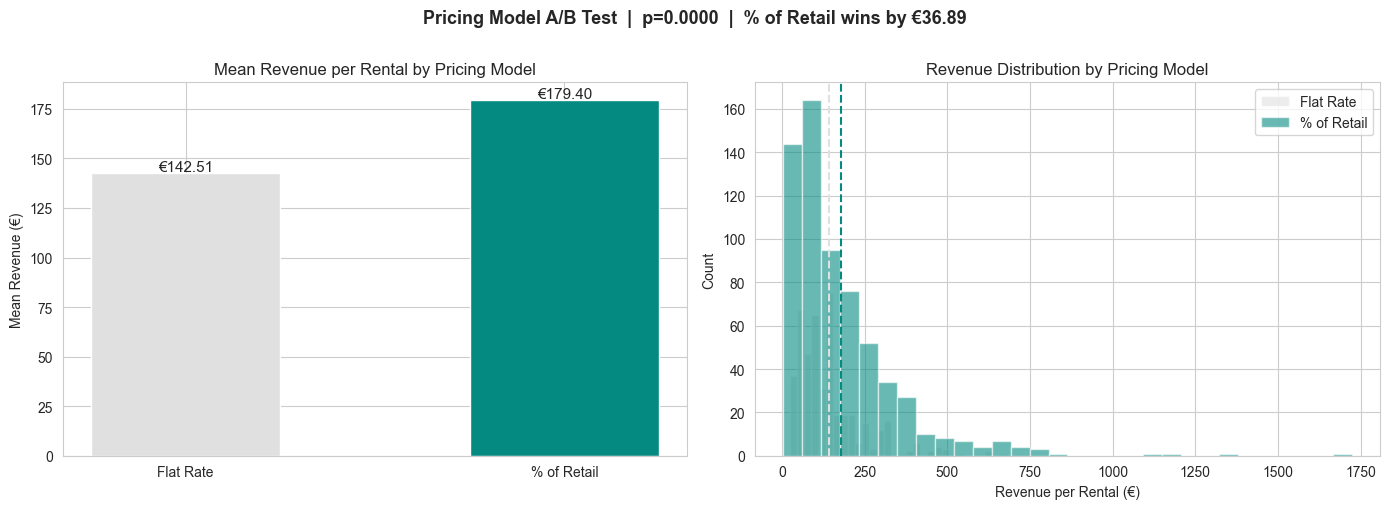

In [3]:
# Does pricing model (flat rate vs % of retail) affect revenue per rental?
# We use Welch's t-test because the two groups have unequal sizes and unequal variance
group_flat = ab_data[ab_data["pricing_model"] == "flat_rate"]["total_rental_revenue"]
group_pct  = ab_data[ab_data["pricing_model"] == "pct_of_retail"]["total_rental_revenue"]

t_stat, p_value = stats.ttest_ind(group_flat, group_pct, equal_var=False)

print("A/B TEST: PRICING MODEL")
print(f"Flat Rate   — n={len(group_flat):,}, mean=€{group_flat.mean():.2f}")
print(f"% of Retail — n={len(group_pct):,}, mean=€{group_pct.mean():.2f}")
print(f"Welch's t-test: t={t_stat:.4f}, p={p_value:.6f}")
print(f"Result: {'Significant difference' if p_value < 0.05 else 'No significant difference'} (α=0.05)")

winner = '% of Retail' if group_pct.mean() > group_flat.mean() else 'Flat Rate'
lift = abs(group_pct.mean() - group_flat.mean())
print(f"Revenue lift: €{lift:.2f} per rental ({winner} wins)")

# Visualise the two distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean revenue per group
groups   = ['Flat Rate', '% of Retail']
means    = [group_flat.mean(), group_pct.mean()]
colours  = [C_GREY, C_TEAL]
bars = axes[0].bar(groups, means, color=colours, edgecolor='white', width=0.5)
axes[0].set_title('Mean Revenue per Rental by Pricing Model')
axes[0].set_ylabel('Mean Revenue (€)')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'€{val:.2f}', ha='center', fontsize=11)

# Right: revenue distributions (overlapping histograms)
axes[1].hist(group_flat, bins=30, alpha=0.6, color=C_GREY,  edgecolor='white', label='Flat Rate')
axes[1].hist(group_pct,  bins=30, alpha=0.6, color=C_TEAL,  edgecolor='white', label='% of Retail')
axes[1].axvline(group_flat.mean(), color=C_GREY,   linestyle='--', linewidth=1.5)
axes[1].axvline(group_pct.mean(),  color=C_TEAL,   linestyle='--', linewidth=1.5)
axes[1].set_title('Revenue Distribution by Pricing Model')
axes[1].set_xlabel('Revenue per Rental (€)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Pricing Model A/B Test  |  p={p_value:.4f}  |  {winner} wins by €{lift:.2f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ab_pricing_model.png", dpi=150, bbox_inches='tight')
plt.show()

## 2 · A/B Test: Duration Model (7-day vs 30-day vs Flexible)
**Hypothesis:** All three duration models generate the same revenue per rental.

A/B TEST: DURATION MODEL (ANOVA)
  7_day      — n=375, mean=€146.81
  30_day     — n=369, mean=€149.54
  flexible   — n=349, mean=€198.11

One-way ANOVA: F=13.2819, p=0.000002
Result: ✅ Significant difference

Pairwise comparisons (Bonferroni-corrected):
  ❌ 7_day vs 30_day: diff=€-2.73, p_adj=1.0000
  ✅ 7_day vs flexible: diff=€-51.31, p_adj=0.0000
  ✅ 30_day vs flexible: diff=€-48.57, p_adj=0.0002


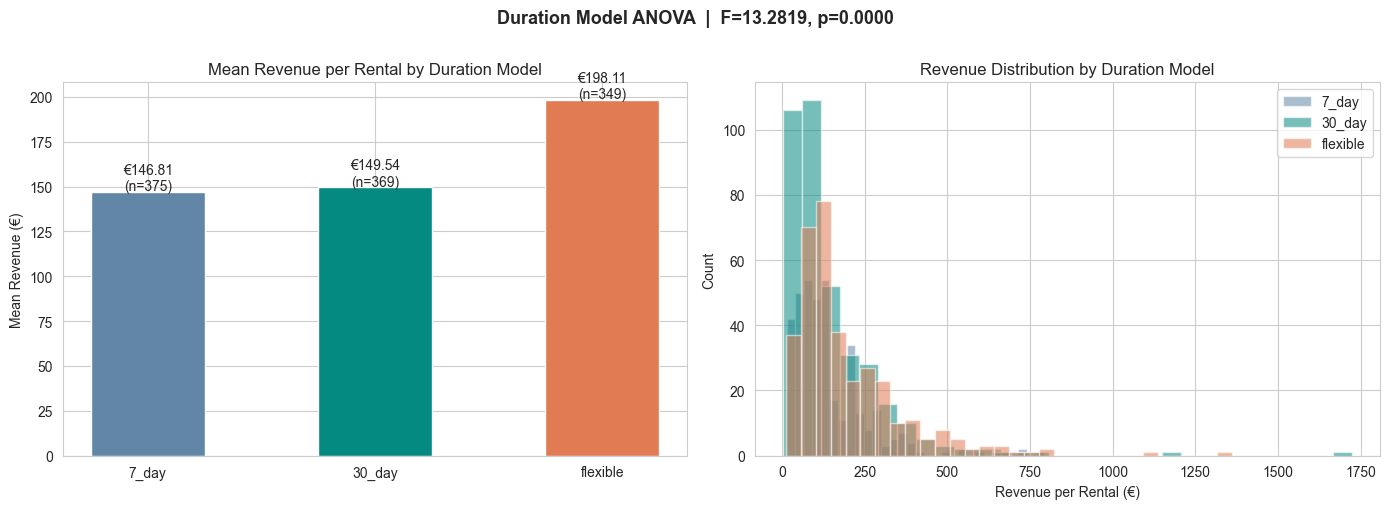

In [4]:
# Does rental duration model (7-day, 30-day, flexible) affect revenue?
# We use ANOVA instead of t-test because we're comparing 3 groups, not 2
# Running multiple t-tests would inflate the chance of a false positive
dur_groups = {}
for model in ["7_day", "30_day", "flexible"]:
    dur_groups[model] = ab_data[ab_data["duration_model"] == model]["total_rental_revenue"]

f_stat, p_value_anova = stats.f_oneway(*dur_groups.values())

print("=" * 50)
print("A/B TEST: DURATION MODEL (ANOVA)")
print("=" * 50)
for model, data in dur_groups.items():
    print(f"  {model:10s} — n={len(data):,}, mean=€{data.mean():.2f}")
print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_value_anova:.6f}")
print(f"Result: {'✅ Significant difference' if p_value_anova < 0.05 else '❌ No significant difference'}")

# If significant, run pairwise comparisons with Bonferroni correction
# Bonferroni divides the significance threshold by number of comparisons
# to avoid false positives when testing multiple pairs
if p_value_anova < 0.05:
    from itertools import combinations
    print("\nPairwise comparisons (Bonferroni-corrected):")
    pairs = list(combinations(dur_groups.keys(), 2))
    for a, b in pairs:
        t, p = stats.ttest_ind(dur_groups[a], dur_groups[b], equal_var=False)
        p_adj = min(p * len(pairs), 1.0)
        sig = "✅" if p_adj < 0.05 else "❌"
        print(f"  {sig} {a} vs {b}: diff=€{dur_groups[a].mean()-dur_groups[b].mean():.2f}, p_adj={p_adj:.4f}")

# Visualise mean revenue by duration model
labels = list(dur_groups.keys())
means  = [dur_groups[m].mean() for m in labels]
counts = [len(dur_groups[m]) for m in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(labels, means, color=[C_BLUE, C_TEAL, C_ORANGE], edgecolor='white', width=0.5)
axes[0].set_title('Mean Revenue per Rental by Duration Model')
axes[0].set_ylabel('Mean Revenue (€)')
for bar, val, n in zip(bars, means, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'€{val:.2f}\n(n={n:,})', ha='center', fontsize=10)

colours = [C_BLUE, C_TEAL, C_ORANGE]
for (model, data), colour in zip(dur_groups.items(), colours):
    axes[1].hist(data, bins=30, alpha=0.55, color=colour, edgecolor='white', label=model)
axes[1].set_title('Revenue Distribution by Duration Model')
axes[1].set_xlabel('Revenue per Rental (€)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Duration Model ANOVA  |  F={f_stat:.4f}, p={p_value_anova:.4f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/ab_duration_model.png", dpi=150, bbox_inches='tight')
plt.show()

## 3 · Core Hypothesis — Rental vs Graduated Discount

**Thesis:** Renting unsold items (listed 12+ months) generates more lifetime revenue than a graduated markdown based on age and depreciation class.

**Discount schedule (as implemented in `01_data_generation.ipynb`):**

| Months Unsold | Fast (phones/laptops) | Standard (drones/cameras) | Slow (TVs/appliances) |
|---|---|---|---|
| ≤ 12 months | 45% off | 35% off | 25% off |
| ≤ 18 months | 55% off | 45% off | 35% off |
| ≤ 24 months | 70% off | 65% off | 55% off |
| 24+ months  | 75% off | 72% off | 65% off |

Source: SellCell annual depreciation report; EverTrade IT asset resale curves.

**Model assumptions (optimistic by design):**
- Operational costs modelled at 15–25% — real programmes run 35–50% all-in
- No storage or refurbishment costs between rentals
- Win rate of ~60% is the ceiling; real-world estimate is 40–55%
- Sensitivity analysis and Monte Carlo stress-testing are in `04_machine_learning.ipynb` (Sections 4a–4b)


One-sample t-test (H₀: ratio = 1.0):
  Median ratio (honest):  1.27×  ← use this for reporting
  Mean ratio (skewed):    2.61×  ← inflated by early-listed products
  t=6.7782, p=4.26e-11
  ✅ Rental is significantly more profitable (p < 0.05)


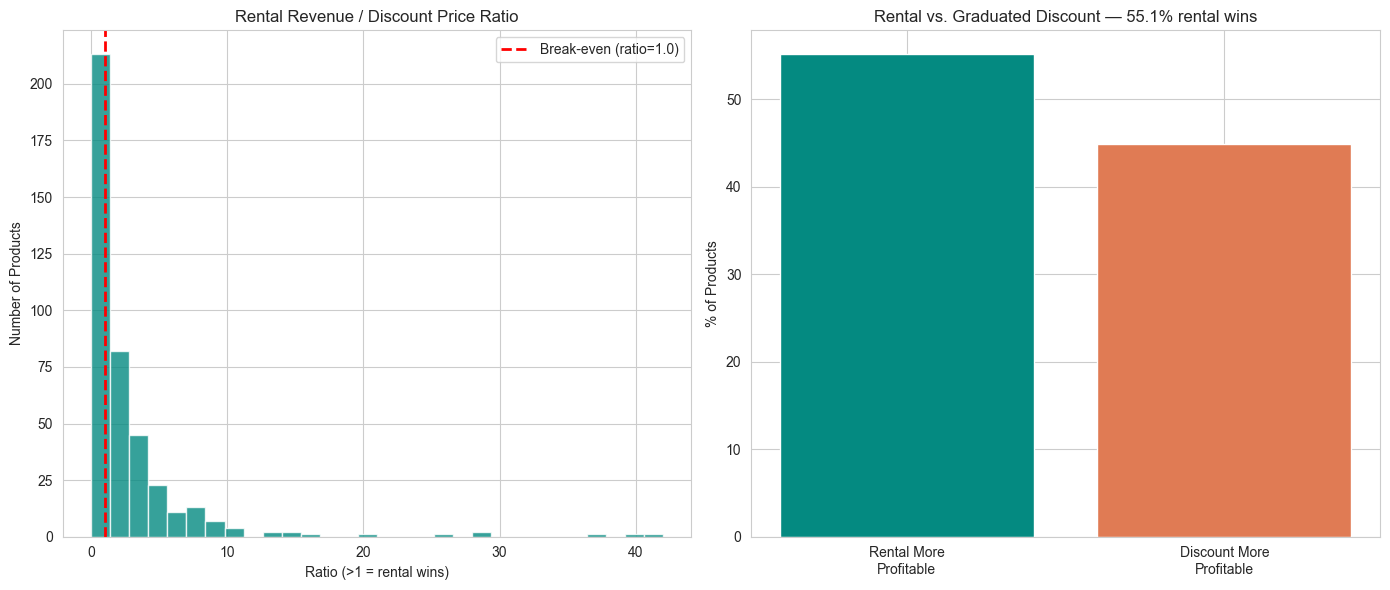

In [5]:
# Is the rental/discount ratio significantly greater than 1.0 (break-even)?
# We use a one-sample t-test: we're not comparing two groups,
# we're asking "is this one distribution meaningfully above a fixed value?"
t_stat, p_value = stats.ttest_1samp(comparison["rental_vs_discount_ratio"], popmean=1.0)

median_ratio = comparison["rental_vs_discount_ratio"].median()
mean_ratio   = comparison["rental_vs_discount_ratio"].mean()

print(f"\nOne-sample t-test (H₀: ratio = 1.0):")
print(f"  Median ratio (honest):  {median_ratio:.2f}×  ← use this for reporting")
print(f"  Mean ratio (skewed):    {mean_ratio:.2f}×  ← inflated by early-listed products")
print(f"  t={t_stat:.4f}, p={p_value:.2e}")
print(f"  {'✅ Rental is significantly more profitable (p < 0.05)' if p_value < 0.05 and t_stat > 0 else '❌ Not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(comparison["rental_vs_discount_ratio"], bins=30, color=C_TEAL, edgecolor="white", alpha=0.8)
axes[0].axvline(x=1.0, color="red", linestyle="--", linewidth=2, label="Break-even (ratio=1.0)")
axes[0].set_title("Rental Revenue / Discount Price Ratio")
axes[0].set_xlabel("Ratio (>1 = rental wins)")
axes[0].set_ylabel("Number of Products")
axes[0].legend()

profitable_pct = comparison["is_rental_more_profitable"].mean() * 100
axes[1].bar(["Rental More\nProfitable", "Discount More\nProfitable"],
            [profitable_pct, 100 - profitable_pct],
            color=[C_TEAL, C_ORANGE])
axes[1].set_ylabel("% of Products")
axes[1].set_title(f"Rental vs. Graduated Discount — {profitable_pct:.1f}% rental wins")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rental_vs_discount.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Bootstrap Confidence Intervals — Win Rate

The t-test in Section 3 tells us the rental advantage is statistically significant. But *how wide* is our uncertainty? Bootstrap CI gives us the honest answer.

We resample the win/loss outcomes 5,000 times and measure where 95% of those estimates fall. The key question: does the entire confidence interval stay above 50%? If yes, we are 95% confident the rental programme beats markdown more often than not — even under the worst likely draw of our data.

Point estimate:          55.1%
95% CI:                  50.2% → 60.0%
Entire CI above 50%:     Yes → rental wins more than half the time even in worst case

Connecting to Section 3: the t-test showed the mean ratio is significantly > 1.0.
This CI confirms the win rate itself is also robustly above 50% — both metrics point the same way.


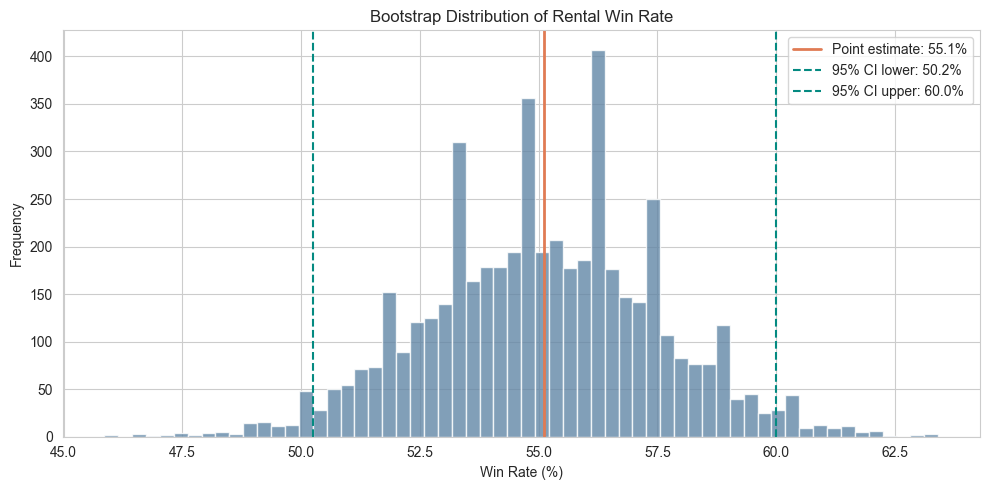

In [6]:
# How confident are we in the 60% win rate? Bootstrap gives us a range.
# Idea: resample our data 5000 times, calculate win rate each time,
# then see where 95% of those estimates fall
n_boot = 5000
boot_wins = []
win_arr = comparison["is_rental_more_profitable"].values

for _ in range(n_boot):
    # Draw a random sample the same size as our data, with replacement
    sample = np.random.choice(win_arr, size=len(win_arr), replace=True)
    # Record the win rate for this sample
    boot_wins.append(sample.mean() * 100)

boot_wins = np.array(boot_wins)

# The 2.5th and 97.5th percentiles give us the 95% confidence interval
ci_low, ci_high = np.percentile(boot_wins, [2.5, 97.5])
point_est = win_arr.mean() * 100

print(f"Point estimate:          {point_est:.1f}%")
print(f"95% CI:                  {ci_low:.1f}% → {ci_high:.1f}%")
print(f"Entire CI above 50%:     {'Yes → rental wins more than half the time even in worst case' if ci_low > 50 else 'No → result is not conclusive at the lower bound'}")
print(f"\nConnecting to Section 3: the t-test showed the mean ratio is significantly > 1.0.")
print(f"This CI confirms the win rate itself is also robustly above 50% — both metrics point the same way.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_wins, bins=60, color=C_BLUE, edgecolor="white", alpha=0.8)
ax.axvline(point_est, color=C_ORANGE, linewidth=2, label=f"Point estimate: {point_est:.1f}%")
ax.axvline(ci_low, color=C_TEAL, linewidth=1.5, linestyle="--", label=f"95% CI lower: {ci_low:.1f}%")
ax.axvline(ci_high, color=C_TEAL, linewidth=1.5, linestyle="--", label=f"95% CI upper: {ci_high:.1f}%")
ax.set_title("Bootstrap Distribution of Rental Win Rate")
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()


---
## ✅ A/B Testing Deliverables

| # | Test | Method | Chart |
|---|---|---|---|
| 1 | Pricing model (Flat Rate vs % of Retail) | Welch's t-test | `ab_pricing_model.png` |
| 2 | Duration model (7-day vs 30-day vs Flexible) | One-way ANOVA + Bonferroni post-hoc | `ab_duration_model.png` |
| 3 | Core hypothesis (rental vs graduated discount) | One-sample t-test (H₀: ratio = 1.0) | `rental_vs_discount.png` |
| 4 | Win rate uncertainty | Bootstrap 95% CI (5,000 resamples) | `bootstrap_ci.png` |

> Results are computed at runtime — check the printed output above each chart for the actual numbers.

**→ Proceed to `04_machine_learning.ipynb`**